**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 11 Sep 2025**
<br>
**Lab - 12**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('rd.xlsx')
print("First 5 rows of the Raisin Dataset:")
df.head()

First 5 rows of the Raisin Dataset:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [4]:
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
print("Target variable encoded.")
print("Kecimen ->", le.transform(['Kecimen'])[0])
print("Besni   ->", le.transform(['Besni'])[0])
df.head()

Target variable encoded.
Kecimen -> 1
Besni   -> 0


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,1
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,1
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,1
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,1
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,1


In [5]:
X = df.drop('Class', axis=1)
y = df['Class']
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores for each feature:")
print(mi_scores)
least_important_feature = mi_scores.index[-1]
print(f"\nThe least important feature is: '{least_important_feature}'")
X_screened = X.drop(columns=[least_important_feature])
print(f"'{least_important_feature}' has been dropped.")

Mutual Information Scores for each feature:
Perimeter          0.358507
MajorAxisLength    0.348341
ConvexArea         0.297530
Area               0.277582
MinorAxisLength    0.134869
Eccentricity       0.129117
Extent             0.029344
Name: MI Scores, dtype: float64

The least important feature is: 'Extent'
'Extent' has been dropped.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_screened, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (720, 6)
Testing set shape: (180, 6)


--- Evaluation Metrics for: Default Bagging ---
Accuracy: 0.8333
Precision: 0.7830
Recall: 0.9222
F1-Score: 0.8469

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82        90
           1       0.78      0.92      0.85        90

    accuracy                           0.83       180
   macro avg       0.84      0.83      0.83       180
weighted avg       0.84      0.83      0.83       180



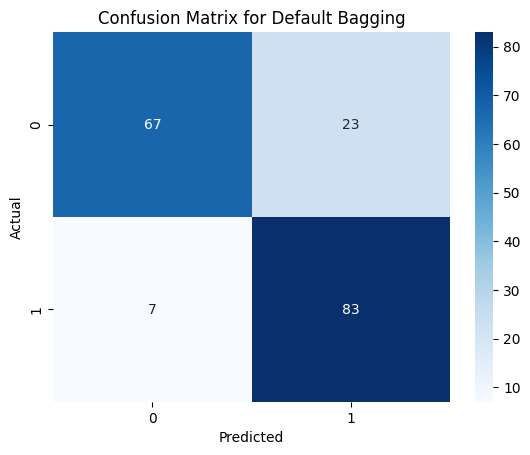

In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"--- Evaluation Metrics for: {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)
bagging_clf.fit(X_train, y_train)
default_bagging_metrics = evaluate_model("Default Bagging", bagging_clf, X_test, y_test)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters for Bagging Classifier: {'estimator__max_depth': 5, 'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 50}
--- Evaluation Metrics for: Tuned Bagging ---
Accuracy: 0.8556
Precision: 0.8019
Recall: 0.9444
F1-Score: 0.8673

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84        90
           1       0.80      0.94      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.85       180
weighted avg       0.87      0.86      0.85       180



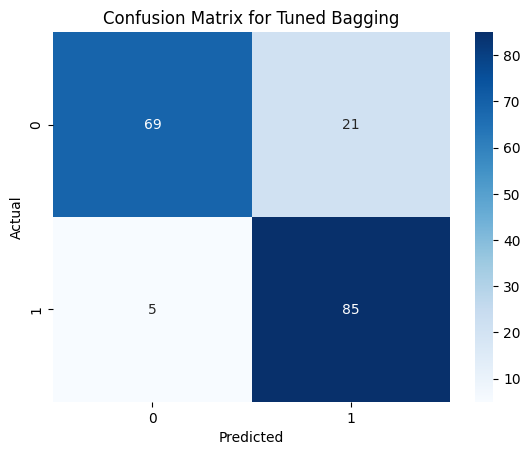

In [11]:
param_grid_bagging = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 1.0],
    'estimator__max_depth': [3, 5, None]
}
grid_search_bagging = GridSearchCV(
    estimator=BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    param_grid=param_grid_bagging,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_bagging.fit(X_train, y_train)
best_bagging_clf = grid_search_bagging.best_estimator_
print("\nBest Parameters for Bagging Classifier:", grid_search_bagging.best_params_)
tuned_bagging_metrics = evaluate_model("Tuned Bagging", best_bagging_clf, X_test, y_test)

--- Evaluation Metrics for: Default Random Forest ---
Accuracy: 0.8556
Precision: 0.8077
Recall: 0.9333
F1-Score: 0.8660

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.78      0.84        90
           1       0.81      0.93      0.87        90

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.85       180
weighted avg       0.86      0.86      0.85       180



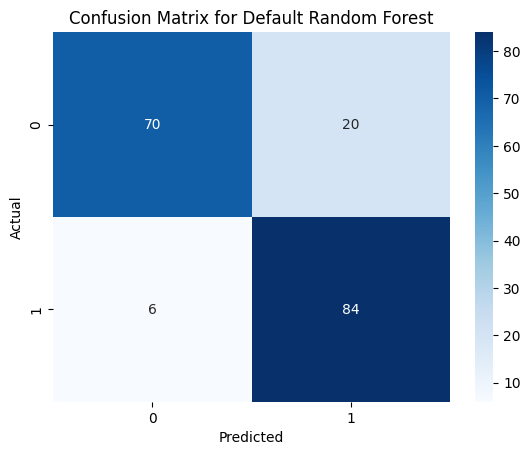

In [12]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
default_rf_metrics = evaluate_model("Default Random Forest", rf_clf, X_test, y_test)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters for Random Forest: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
--- Evaluation Metrics for: Tuned Random Forest ---
Accuracy: 0.8667
Precision: 0.8113
Recall: 0.9556
F1-Score: 0.8776

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.85        90
           1       0.81      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



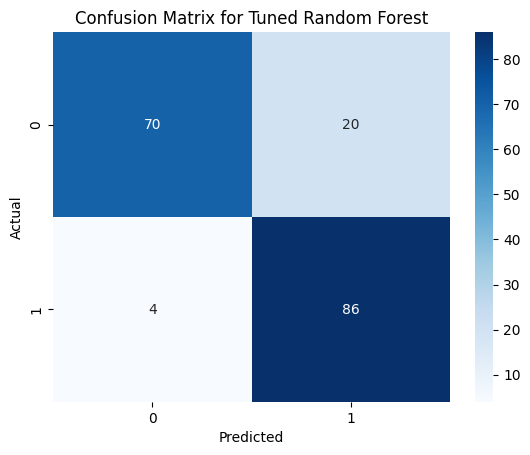

In [13]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.7]
}
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)
best_rf_clf = grid_search_rf.best_estimator_
print("\nBest Parameters for Random Forest:", grid_search_rf.best_params_)
tuned_rf_metrics = evaluate_model("Tuned Random Forest", best_rf_clf, X_test, y_test)

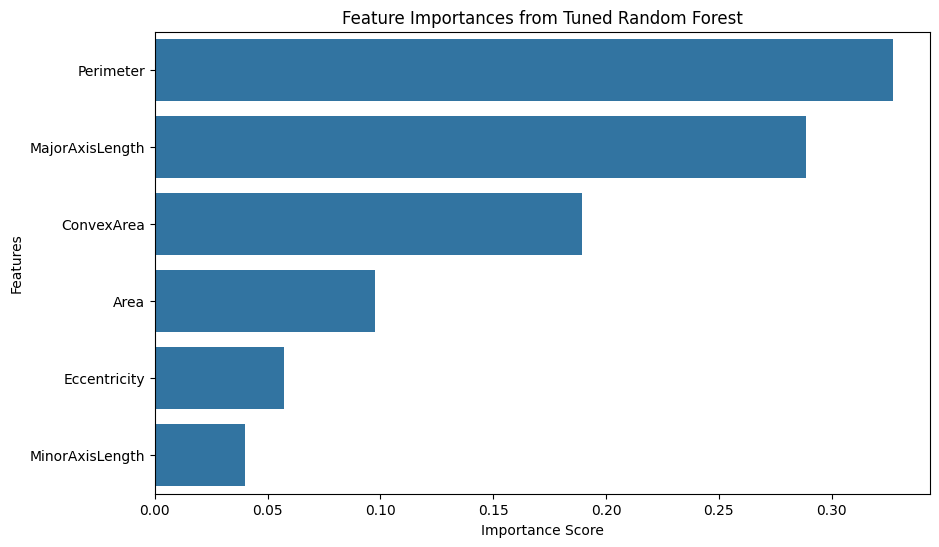

In [14]:
importances = best_rf_clf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances, y=forest_importances.index)
plt.title('Feature Importances from Tuned Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

--- Evaluation Metrics for: Default AdaBoost ---
Accuracy: 0.8667
Precision: 0.8438
Recall: 0.9000
F1-Score: 0.8710

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        90
           1       0.84      0.90      0.87        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180



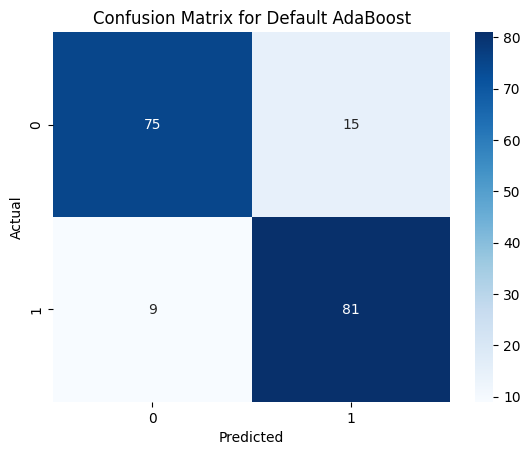

In [15]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    random_state=42
)
ada_clf.fit(X_train, y_train)
default_ada_metrics = evaluate_model("Default AdaBoost", ada_clf, X_test, y_test)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters for AdaBoost: {'estimator__max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 50}
--- Evaluation Metrics for: Tuned AdaBoost ---
Accuracy: 0.8611
Precision: 0.8037
Recall: 0.9556
F1-Score: 0.8731

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.77      0.85        90
           1       0.80      0.96      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



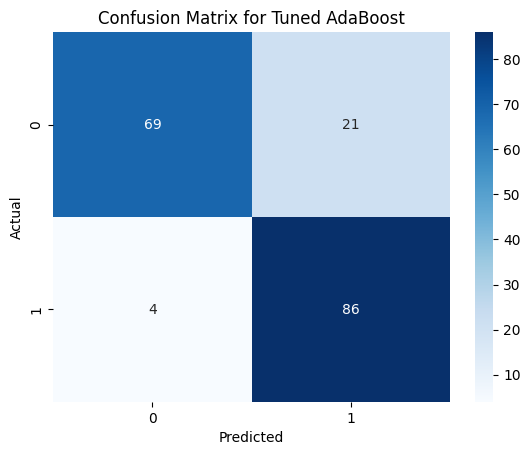

In [17]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2]
}
grid_search_ada = GridSearchCV(
    estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    param_grid=param_grid_ada,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_ada.fit(X_train, y_train)
best_ada_clf = grid_search_ada.best_estimator_
print("\nBest Parameters for AdaBoost:", grid_search_ada.best_params_)
tuned_ada_metrics = evaluate_model("Tuned AdaBoost", best_ada_clf, X_test, y_test)

--- Evaluation Metrics for: Default Gradient Boosting ---
Accuracy: 0.8722
Precision: 0.8317
Recall: 0.9333
F1-Score: 0.8796

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86        90
           1       0.83      0.93      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



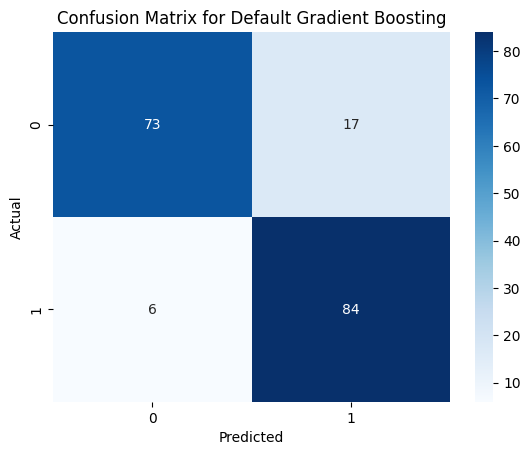

In [19]:
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)
default_gb_metrics = evaluate_model("Default Gradient Boosting", gb_clf, X_test, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
--- Evaluation Metrics for: Tuned Gradient Boosting ---
Accuracy: 0.8778
Precision: 0.8269
Recall: 0.9556
F1-Score: 0.8866

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87        90
           1       0.83      0.96      0.89        90

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180



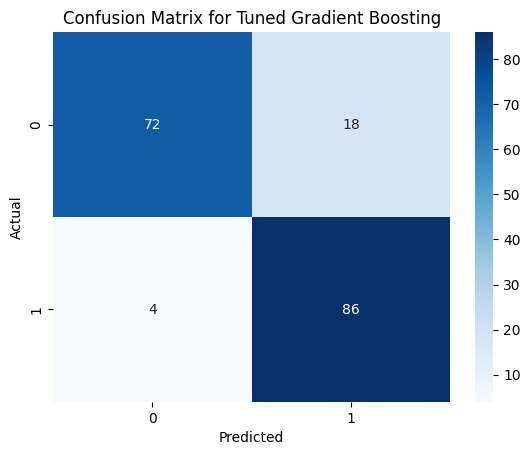

In [20]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5],
    'subsample': [0.8, 1.0]
}
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(X_train, y_train)
best_gb_clf = grid_search_gb.best_estimator_
print("\nBest Parameters for Gradient Boosting:", grid_search_gb.best_params_)
tuned_gb_metrics = evaluate_model("Tuned Gradient Boosting", best_gb_clf, X_test, y_test)

--- Evaluation Metrics for: Voting (Hard) ---
Accuracy: 0.8722
Precision: 0.8190
Recall: 0.9556
F1-Score: 0.8821

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86        90
           1       0.82      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



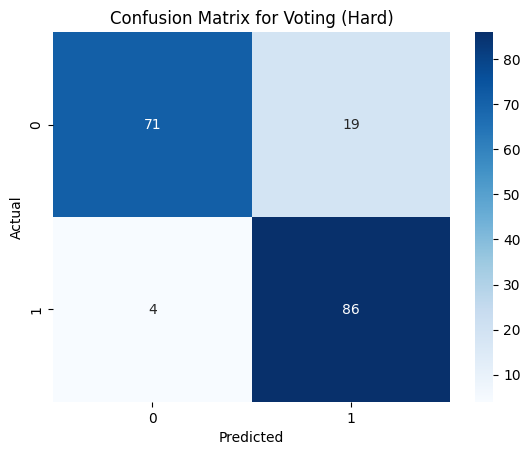

--- Evaluation Metrics for: Voting (Soft) ---
Accuracy: 0.8778
Precision: 0.8269
Recall: 0.9556
F1-Score: 0.8866

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87        90
           1       0.83      0.96      0.89        90

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180



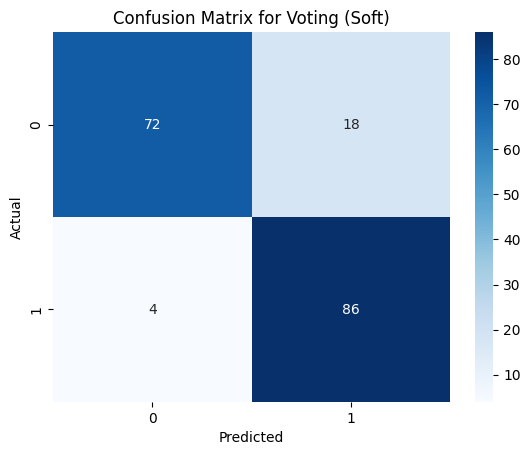

In [21]:
estimators = [
    ('rf', best_rf_clf),
    ('gb', best_gb_clf),
    ('lr', LogisticRegression(random_state=42))
]
hard_voting_clf = VotingClassifier(estimators=estimators, voting='hard')
hard_voting_clf.fit(X_train, y_train)
voting_hard_metrics = evaluate_model("Voting (Hard)", hard_voting_clf, X_test, y_test)
soft_voting_clf = VotingClassifier(estimators=estimators, voting='soft')
soft_voting_clf.fit(X_train, y_train)
voting_soft_metrics = evaluate_model("Voting (Soft)", soft_voting_clf, X_test, y_test)

--- Evaluation Metrics for: Stacking ---
Accuracy: 0.8667
Precision: 0.8235
Recall: 0.9333
F1-Score: 0.8750

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.86        90
           1       0.82      0.93      0.88        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180



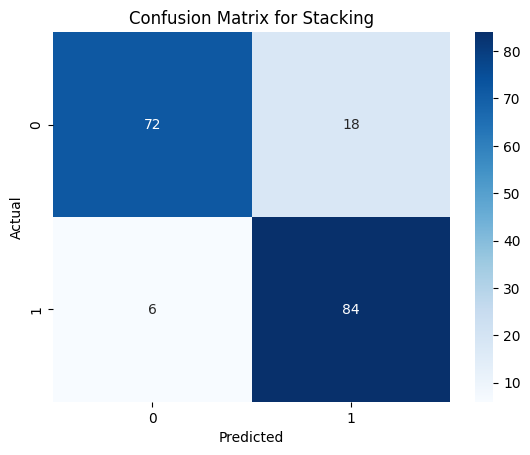

In [22]:
base_learners = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('rf', best_rf_clf),
    ('gb', best_gb_clf)
]
meta_learner = LogisticRegression()
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stacking_clf.fit(X_train, y_train)
stacking_metrics = evaluate_model("Stacking", stacking_clf, X_test, y_test)

In [23]:
all_metrics = [
    tuned_bagging_metrics,
    tuned_rf_metrics,
    tuned_ada_metrics,
    tuned_gb_metrics,
    voting_hard_metrics,
    voting_soft_metrics,
    stacking_metrics
]
results_df = pd.DataFrame(all_metrics)
results_df.set_index('Model', inplace=True)
print("--- Final Performance Comparison ---")
results_df

--- Final Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Tuned Bagging,0.855556,0.801887,0.944444,0.867347
Tuned Random Forest,0.866667,0.811321,0.955556,0.877551
Tuned AdaBoost,0.861111,0.803738,0.955556,0.873096
Tuned Gradient Boosting,0.877778,0.826923,0.955556,0.886598
Voting (Hard),0.872222,0.819048,0.955556,0.882051
Voting (Soft),0.877778,0.826923,0.955556,0.886598
Stacking,0.866667,0.823529,0.933333,0.875000


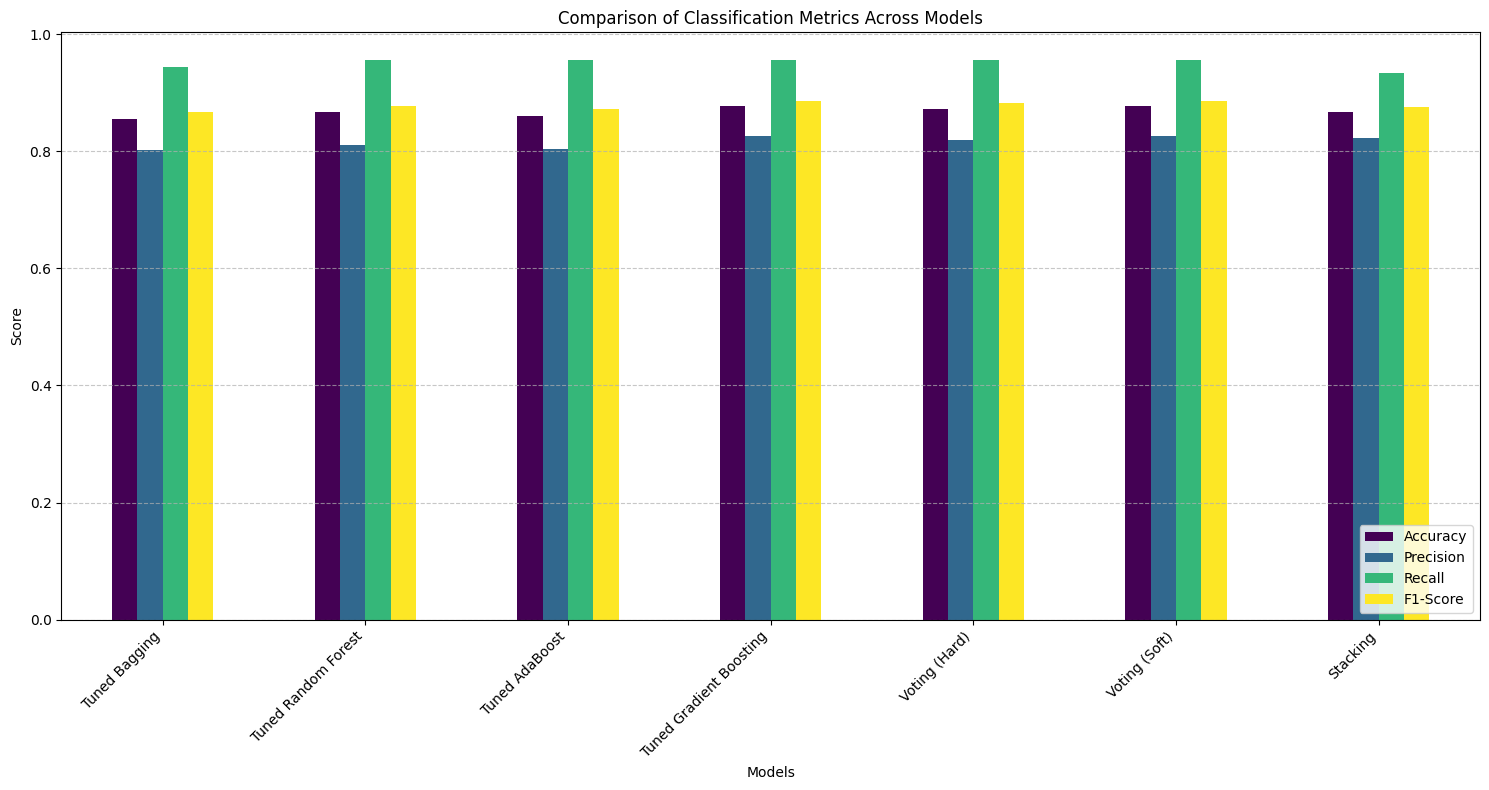

In [26]:
results_df.plot(kind='bar', figsize=(15, 8), colormap='viridis')
plt.title('Comparison of Classification Metrics Across Models')
plt.ylabel('Score')
plt.xlabel('Models')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()